# Transformer Encoder from Scratch for Sequence Reversal

In this notebook, We implement a basic transformer encoder from scratch in PyTorch to understand how transformers work under the hood. The task is to train the model to reverse a sequence of five digits, where each digit is an integer from 1 to 9.

For example:

Input: `[3, 5, 2, 4, 1]`  
Output: `[1, 4, 2, 5, 3]`

The transformer is implemented using only basic PyTorch primitives such as `nn.Linear`, `nn.LayerNorm`, `nn.Parameter`, tensor operations, optimization tools, and loss functions. High-level transformer components such as `nn.Embedding`, `nn.MultiheadAttention`, and `nn.TransformerEncoder` are not used.

The notebook is organized step by step, including:
- implementation of each transformer component,
- generation of synthetic data,
- training,
- prediction,
- evaluation,
- and an architecture diagram.

In [3]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Define the Synthetic Dataset and Vocabulary

The task is to train a transformer encoder to reverse sequences of length 5. Each token in the sequence is a digit from 1 to 9. For example, the input sequence `[3, 5, 2, 4, 1]` should produce the output `[1, 4, 2, 5, 3]`.

Since the digits already behave like discrete tokens, we can represent each sequence directly as a list of integers. The target sequence is simply the reversed version of the input.

For this implementation:
- sequence length = 5
- valid tokens = 1 to 9
- vocabulary size = 10, reserving index 0 as an unused padding-style slot
- output classes = 10, so the model predicts one token at each output position

In [4]:
# Task configuration
SEQ_LEN = 5
MIN_DIGIT = 1
MAX_DIGIT = 9
VOCAB_SIZE = 10   # digits 0-9, where 0 is unused
NUM_CLASSES = VOCAB_SIZE

print("Sequence length:", SEQ_LEN)
print("Valid digits:", MIN_DIGIT, "to", MAX_DIGIT)
print("Vocabulary size:", VOCAB_SIZE)
print("Number of output classes:", NUM_CLASSES)

Sequence length: 5
Valid digits: 1 to 9
Vocabulary size: 10
Number of output classes: 10


## 2. Generate the Synthetic Dataset

We generate a synthetic dataset for the sequence-reversal task. Each input sequence contains 5 digits, where each digit is an integer from 1 to 9. The target sequence is simply the reversed version of the input.

For example:

- Input: `[3, 5, 2, 4, 1]`
- Target: `[1, 4, 2, 5, 3]`

This dataset is simple enough to let us focus on implementing the transformer architecture from scratch, while still requiring the model to learn relationships between token positions.

Since the input data consists of integers between 1 and 9, it is already in a tokenized form. Therefore, no additional tokenization step is required. Each digit directly represents a token, where the integer value serves as the token index used by the embedding layer. 

In [5]:
def generate_sequence(seq_len=SEQ_LEN, min_digit=MIN_DIGIT, max_digit=MAX_DIGIT):
    sequence = [random.randint(min_digit, max_digit) for _ in range(seq_len)]
    reversed_sequence = sequence[::-1]
    return sequence, reversed_sequence


def generate_dataset(num_samples, seq_len=SEQ_LEN, min_digit=MIN_DIGIT, max_digit=MAX_DIGIT):
    inputs = []
    targets = []
    
    for _ in range(num_samples):
        x, y = generate_sequence(seq_len, min_digit, max_digit)
        inputs.append(x)
        targets.append(y)
    
    return torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)


# Generate training and test sets
X_train, y_train = generate_dataset(5000)
X_test, y_test = generate_dataset(1000)

print("Training input shape :", X_train.shape)
print("Training target shape:", y_train.shape)
print("Test input shape     :", X_test.shape)
print("Test target shape    :", y_test.shape)

# Show a few examples
for i in range(3):
    print(f"Example {i+1}")
    print("Input :", X_train[i].tolist())
    print("Target:", y_train[i].tolist())
    print()

Training input shape : torch.Size([5000, 5])
Training target shape: torch.Size([5000, 5])
Test input shape     : torch.Size([1000, 5])
Test target shape    : torch.Size([1000, 5])
Example 1
Input : [2, 1, 5, 4, 4]
Target: [4, 4, 5, 1, 2]

Example 2
Input : [3, 2, 9, 2, 7]
Target: [7, 2, 9, 2, 3]

Example 3
Input : [1, 1, 2, 4, 4]
Target: [4, 4, 2, 1, 1]



## 3. Create DataLoaders for Training and Testing

We wrap the input and target tensors into PyTorch datasets and then create data loaders for batching. This allows us to train the model efficiently using mini-batches rather than processing the entire dataset at once.

We use shuffling for the training data so that the model sees the examples in a different order each epoch. For the test data, shuffling is not necessary.

In [6]:
from torch.utils.data import TensorDataset, DataLoader

# Create PyTorch datasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Create data loaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Inspect one batch
sample_x, sample_y = next(iter(train_loader))
print("Batch input shape :", sample_x.shape)
print("Batch target shape:", sample_y.shape)
print()
print("Sample batch input:")
print(sample_x[:2])
print()
print("Sample batch target:")
print(sample_y[:2])

Batch input shape : torch.Size([64, 5])
Batch target shape: torch.Size([64, 5])

Sample batch input:
tensor([[9, 1, 9, 2, 8],
        [1, 8, 3, 2, 6]])

Sample batch target:
tensor([[8, 2, 9, 1, 9],
        [6, 2, 3, 8, 1]])


## 4. Implement the Token Embedding Layer

The first step in the transformer is to convert each discrete token into a dense vector representation. Instead of using `nn.Embedding`, which is not allowed in this assignment, we implement the embedding manually using a learned weight matrix.

If the vocabulary size is $|\mathcal{V}|$ and the embedding dimension is $d_{\text{model}}$, then the embedding matrix has shape $(|\mathcal{V}|, d_{\text{model}})$. Each token index is used to look up one row of this matrix.

Importantly, this embedding matrix is **learnable**. It is initialized randomly and updated during training through backpropagation. As training progresses, the model learns meaningful vector representations for each token, allowing it to capture relationships between different digits in a continuous space.

The output shape is:

- Input: `(batch_size, seq_len)`
- Output: `(batch_size, seq_len, d_model)`

In [7]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding_weight = nn.Parameter(torch.randn(vocab_size, d_model) * 0.02)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        # output shape: (batch_size, seq_len, d_model)
        return self.embedding_weight[x]


# Test the token embedding layer
D_MODEL = 32

token_embedding = TokenEmbedding(VOCAB_SIZE, D_MODEL)

test_input = torch.tensor([
    [3, 5, 2, 4, 1],
    [9, 1, 7, 3, 6]
], dtype=torch.long)

test_output = token_embedding(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)

Input shape : torch.Size([2, 5])
Output shape: torch.Size([2, 5, 32])


## 5. Implement the Positional Embedding Layer

Because a transformer does not process tokens sequentially like an RNN, it needs positional information to understand the order of tokens in the sequence. We therefore learn a positional embedding matrix and add it to the token embeddings.

If the maximum sequence length is $L$ and the embedding dimension is $d_{\text{model}}$, then the positional embedding matrix has shape $(L, d_{\text{model}})$. Each position in the sequence uses the corresponding row from this matrix.

Importantly, the positional embedding matrix is also **learnable**. It is initialized randomly and updated during training. This allows the model to learn how different positions in the sequence should be represented and how position influences the relationships between tokens.

The output shape is:

- Input: `(batch_size, seq_len, d_model)`
- Output: `(batch_size, seq_len, d_model)`

In [8]:
class PositionalEmbedding(nn.Module):
    def __init__(self, max_seq_len, d_model):
        super().__init__()
        self.position_weight = nn.Parameter(torch.randn(max_seq_len, d_model) * 0.02)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        batch_size, seq_len, d_model = x.shape
        
        positions = torch.arange(seq_len, device=x.device)
        pos_embed = self.position_weight[positions]              # (seq_len, d_model)
        pos_embed = pos_embed.unsqueeze(0).expand(batch_size, seq_len, d_model)
        
        return x + pos_embed


# Test the positional embedding layer
positional_embedding = PositionalEmbedding(SEQ_LEN, D_MODEL)

token_embedded = token_embedding(test_input)
position_embedded = positional_embedding(token_embedded)

print("Token embedding shape     :", token_embedded.shape)
print("Position embedding shape  :", position_embedded.shape)

Token embedding shape     : torch.Size([2, 5, 32])
Position embedding shape  : torch.Size([2, 5, 32])


## 6. Combine Token and Positional Embeddings

The input representation for the transformer is obtained by adding the token embedding and the positional embedding. The token embedding tells the model what the symbol is, while the positional embedding tells the model where that symbol appears in the sequence.

This combined representation is the input that will be passed into the self-attention layer.

The output shape is:

- Input: `(batch_size, seq_len)`
- Output: `(batch_size, seq_len, d_model)`

In [9]:
class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, max_seq_len, d_model):
        super().__init__()
        self.token_embedding = TokenEmbedding(vocab_size, d_model)
        self.positional_embedding = PositionalEmbedding(max_seq_len, d_model)

    def forward(self, x):
        x = self.token_embedding(x)          # (batch_size, seq_len, d_model)
        x = self.positional_embedding(x)     # (batch_size, seq_len, d_model)
        return x


# Test the full input embedding block
input_embedding = InputEmbedding(VOCAB_SIZE, SEQ_LEN, D_MODEL)

embedded_output = input_embedding(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", embedded_output.shape)

Input shape : torch.Size([2, 5])
Output shape: torch.Size([2, 5, 32])


## 7. Implement the Self-Attention Layer

Self-attention allows each token in the sequence to compare itself with every other token and decide which positions are most relevant. This enables the transformer to model relationships between tokens without using recurrence.

To compute self-attention, we transform the input into three matrices:

- Query ($Q$)
- Key ($K$)
- Value ($V$)

These are learned linear transformations of the input.

We compute attention scores as:

$\text{AttentionScores} = \frac{QK^T}{\sqrt{d_k}}$

Then we apply the softmax function to obtain attention weights:

$\text{AttentionWeights} = \text{softmax}(\text{AttentionScores})$

Finally, we compute the output as a weighted sum of the values:

$\text{Output} = \text{AttentionWeights} \cdot V$

In this implementation, we also return the attention weights to help us inspect how the model distributes attention across the sequence.

The output shapes are:

- Output: `(batch_size, seq_len, d_model)`
- Attention weights: `(batch_size, seq_len, seq_len)`

In [11]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        
        Q = self.W_q(x)   # (batch_size, seq_len, d_model)
        K = self.W_k(x)   # (batch_size, seq_len, d_model)
        V = self.W_v(x)   # (batch_size, seq_len, d_model)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_model)
        attention_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, V)

        return output, attention_weights


# Test the updated self-attention layer
self_attention = SelfAttention(D_MODEL)

attention_output, attention_weights = self_attention(embedded_output)

print("Attention output shape :", attention_output.shape)
print("Attention weights shape:", attention_weights.shape)
print()
print("Attention weights for the first example:")
print(attention_weights[0])

Attention output shape : torch.Size([2, 5, 32])
Attention weights shape: torch.Size([2, 5, 5])

Attention weights for the first example:
tensor([[0.2002, 0.2000, 0.2002, 0.1995, 0.2000],
        [0.2002, 0.1999, 0.2003, 0.1996, 0.2000],
        [0.2003, 0.2000, 0.2003, 0.1995, 0.2000],
        [0.2002, 0.2000, 0.2003, 0.1995, 0.2000],
        [0.2002, 0.2001, 0.2002, 0.1996, 0.1999]], grad_fn=<SelectBackward0>)


## 8. Implement the Feed-Forward Network

After the self-attention layer, each token representation is passed through a feed-forward neural network (FFN). This network is applied independently to each position in the sequence.

The feed-forward network consists of two linear layers with a non-linear activation function in between. In this implementation, we use the ReLU activation function.

The transformation is:

$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$

This allows the model to further process and transform the information gathered by the attention mechanism.

The output shape is:

- Input: `(batch_size, seq_len, d_model)`
- Output: `(batch_size, seq_len, d_model)`

In [12]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=64):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        return x


# Test the feed-forward network
ffn = FeedForward(D_MODEL)

ffn_output = ffn(attention_output)

print("Input shape :", attention_output.shape)
print("Output shape:", ffn_output.shape)

Input shape : torch.Size([2, 5, 32])
Output shape: torch.Size([2, 5, 32])


## 9. Add Residual Connections and Layer Normalization

A transformer encoder uses residual connections and layer normalization around both the self-attention layer and the feed-forward network. These operations help stabilize training and preserve useful information from earlier representations.

A residual connection adds the input of a sublayer to its output:

$\text{ResidualOutput} = x + \text{sublayer}(x)$

In this context, the **sublayer** refers to the transformation applied at that stage of the encoder. In our implementation, the two sublayers are:
- the self-attention layer
- the feed-forward network

After applying the residual connection, layer normalization is used to normalize the resulting vector. For each token representation $x \in \mathbb{R}^{d_{\text{model}}}$, layer normalization is computed as:

$\mu = \frac{1}{d_{\text{model}}} \sum_{i=1}^{d_{\text{model}}} x_i$

$\sigma^2 = \frac{1}{d_{\text{model}}} \sum_{i=1}^{d_{\text{model}}} (x_i - \mu)^2$

$\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$

$y_i = \gamma_i \hat{x}_i + \beta_i$

where:
- $\mu$ is the mean of the features
- $\sigma^2$ is the variance
- $\gamma$ and $\beta$ are learnable parameters that scale and shift the normalized values

The final output of this block is:

$\text{LayerNorm}(x + \text{sublayer}(x))$

This operation ensures that the representation remains stable while allowing the model to refine the input through each sublayer.

In [13]:
class AddNorm(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, x, sublayer_output):
        # x shape: (batch_size, seq_len, d_model)
        # sublayer_output shape: (batch_size, seq_len, d_model)
        return self.layer_norm(x + sublayer_output)


# Test AddNorm
add_norm = AddNorm(D_MODEL)

normalized_output = add_norm(attention_input, attention_output)

print("Input shape          :", attention_input.shape)
print("Sublayer output shape:", attention_output.shape)
print("Normalized shape     :", normalized_output.shape)

Input shape          : torch.Size([2, 5, 32])
Sublayer output shape: torch.Size([2, 5, 32])
Normalized shape     : torch.Size([2, 5, 32])


## 10. Implement the Encoder Block

We now combine the main transformer encoder components into a single encoder block. This block includes:

- self-attention
- residual connection followed by layer normalization
- feed-forward network
- another residual connection followed by layer normalization

The encoder block processes the sequence in two main stages. First, self-attention allows each token to gather information from all other tokens. Then, the feed-forward network further transforms each token representation independently.

The input and output of the encoder block both have shape:

- `(batch_size, seq_len, d_model)`

In this implementation, we also return the attention weights so that we can inspect them later.

In [14]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, d_ff=64):
        super().__init__()
        self.self_attention = SelfAttention(d_model)
        self.add_norm1 = AddNorm(d_model)
        self.feed_forward = FeedForward(d_model, d_ff)
        self.add_norm2 = AddNorm(d_model)

    def forward(self, x):
        # Self-attention block
        attention_output, attention_weights = self.self_attention(x)
        x = self.add_norm1(x, attention_output)

        # Feed-forward block
        ffn_output = self.feed_forward(x)
        x = self.add_norm2(x, ffn_output)

        return x, attention_weights


# Test the encoder block
encoder_block = EncoderBlock(D_MODEL, d_ff=64)

encoder_output, encoder_attention_weights = encoder_block(embedded_output)

print("Encoder output shape   :", encoder_output.shape)
print("Attention weights shape:", encoder_attention_weights.shape)

Encoder output shape   : torch.Size([2, 5, 32])
Attention weights shape: torch.Size([2, 5, 5])


## 11. Build the Full Transformer Encoder Model

We now combine all the previously defined components into the complete transformer model for the sequence-reversal task.

The model consists of:

- an input embedding layer, which combines token and positional embeddings
- one encoder block
- a final linear layer (perceptron) that maps each token representation to output scores over the vocabulary

For each position in the sequence, the model outputs a vector of logits of size equal to the vocabulary size. These logits are then used during training with a cross-entropy loss function.

The output shape of the model is:

- Input: `(batch_size, seq_len)`
- Output logits: `(batch_size, seq_len, vocab_size)`

In [15]:
class TransformerEncoderModel(nn.Module):
    def __init__(self, vocab_size, max_seq_len, d_model, d_ff=64):
        super().__init__()
        self.input_embedding = InputEmbedding(vocab_size, max_seq_len, d_model)
        self.encoder_block = EncoderBlock(d_model, d_ff)
        self.output_layer = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = self.input_embedding(x)                      # (batch_size, seq_len, d_model)
        x, attention_weights = self.encoder_block(x)    # (batch_size, seq_len, d_model)
        logits = self.output_layer(x)                   # (batch_size, seq_len, vocab_size)
        return logits, attention_weights


# Test the full model
model = TransformerEncoderModel(
    vocab_size=VOCAB_SIZE,
    max_seq_len=SEQ_LEN,
    d_model=D_MODEL,
    d_ff=64
).to(device)

test_batch = sample_x.to(device)
logits, attention_weights = model(test_batch)

print("Input shape            :", test_batch.shape)
print("Logits shape           :", logits.shape)
print("Attention weights shape:", attention_weights.shape)

Input shape            : torch.Size([64, 5])
Logits shape           : torch.Size([64, 5, 10])
Attention weights shape: torch.Size([64, 5, 5])


## 12. Define the Loss Function and Optimizer

To train the model, we use the cross-entropy loss function. Since the model predicts one token at each position in the sequence, we compare the predicted logits with the target class at each position.

The model output has shape `(batch_size, seq_len, vocab_size)`, while the target has shape `(batch_size, seq_len)`. For `CrossEntropyLoss`, we reshape the logits so that each token prediction is treated as one training example.

Although the model outputs logits (unnormalized scores), these are internally converted into probabilities using the softmax function. For a vector of logits $z$, softmax is defined as:

$p_i = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$

This transforms the logits into a probability distribution over the vocabulary, where all values are positive and sum to 1.

During training, the model focuses on the probability assigned to the correct class. If the predicted probability for the correct token is high, the loss is low. If the probability is low, the loss increases significantly, penalizing the model. This encourages the model to assign higher probability to the correct class over time.

In PyTorch, `nn.CrossEntropyLoss()` combines the softmax operation and the negative log-likelihood loss in a numerically stable way, so we do not need to apply softmax explicitly in the code.

We also define the optimizer that will update the model parameters during training. In this implementation, we use the Adam optimizer.

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 13. Train the Transformer Model

We now train the transformer encoder on the synthetic sequence-reversal dataset.

For each mini-batch, we:

1. move the input and target tensors to the selected device
2. run a forward pass through the model
3. reshape the logits and targets for the loss function
4. compute the loss
5. backpropagate the gradients
6. update the model parameters

We record the average training loss for each epoch so that we can later visualize how the model learns over time.

In [17]:
NUM_EPOCHS = 20
train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits, _ = model(batch_x)
        # logits shape: (batch_size, seq_len, vocab_size)

        loss = criterion(
            logits.view(-1, VOCAB_SIZE),   # (batch_size * seq_len, vocab_size)
            batch_y.view(-1)               # (batch_size * seq_len)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Training Loss: {avg_loss:.4f}")

Epoch 1/20, Training Loss: 2.0302
Epoch 2/20, Training Loss: 1.4689
Epoch 3/20, Training Loss: 0.7996
Epoch 4/20, Training Loss: 0.3306
Epoch 5/20, Training Loss: 0.0178
Epoch 6/20, Training Loss: 0.0067
Epoch 7/20, Training Loss: 0.0043
Epoch 8/20, Training Loss: 0.0032
Epoch 9/20, Training Loss: 0.0025
Epoch 10/20, Training Loss: 0.0020
Epoch 11/20, Training Loss: 0.0016
Epoch 12/20, Training Loss: 0.0014
Epoch 13/20, Training Loss: 0.0012
Epoch 14/20, Training Loss: 0.0010
Epoch 15/20, Training Loss: 0.0009
Epoch 16/20, Training Loss: 0.0008
Epoch 17/20, Training Loss: 0.0007
Epoch 18/20, Training Loss: 0.0006
Epoch 19/20, Training Loss: 0.0006
Epoch 20/20, Training Loss: 0.0005


## 14. Plot the Training Loss Curve

To monitor learning, we plot the average training loss at each epoch. A decreasing loss indicates that the model is learning to map input sequences to their reversed outputs.

This plot helps us verify whether training is progressing as expected.

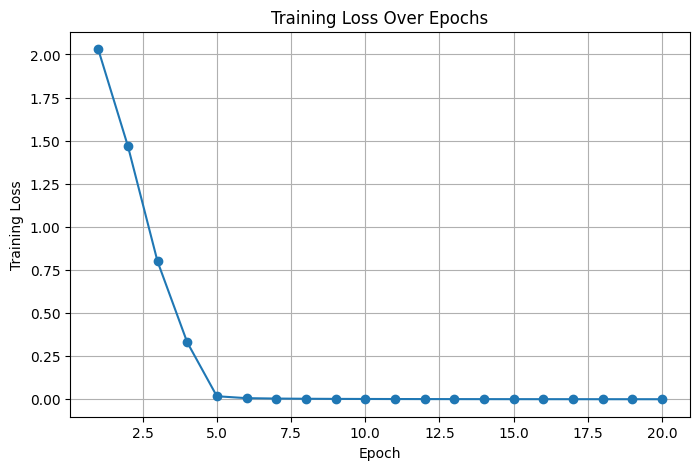

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

## 15. Generate Predictions with the Trained Model

We define a function to generate predictions from the trained model. Given an input sequence, the model outputs logits for each position, representing scores for each possible token in the vocabulary.

To obtain the final predicted token at each position, we apply the argmax function, which selects the index of the largest value in the logits vector. This corresponds to the token with the highest predicted probability.

Although logits are not probabilities, applying softmax would preserve the ordering of values, so the index of the maximum logit is the same as the index of the maximum probability.

This allows us to convert the model output into a sequence of predicted tokens, which we can compare to the expected reversed sequence.

In [23]:
import pandas as pd

def predict(model, input_sequence):
    model.eval()
    
    x = torch.tensor([input_sequence], dtype=torch.long).to(device)
    
    with torch.no_grad():
        logits, _ = model(x)
    
    predictions = torch.argmax(logits, dim=-1)
    
    return predictions[0].cpu().tolist()


# Use real test examples and display nicely
num_examples = 5
rows = []

for i in range(num_examples):
    input_seq = X_test[i].tolist()
    true_seq = y_test[i].tolist()
    pred_seq = predict(model, input_seq)
    
    rows.append({
        "Input": input_seq,
        "Predicted": pred_seq,
        "Expected": true_seq,
        "Correct": pred_seq == true_seq
    })

df = pd.DataFrame(rows)
df

,Input,Predicted,Expected,Correct
0,"[9, 7, 8, 3, 3]","[3, 3, 8, 7, 9]","[3, 3, 8, 7, 9]",True
1,"[9, 9, 4, 1, 5]","[5, 1, 4, 9, 9]","[5, 1, 4, 9, 9]",True
2,"[8, 4, 4, 2, 5]","[5, 2, 4, 4, 8]","[5, 2, 4, 4, 8]",True
3,"[6, 5, 7, 2, 6]","[6, 2, 7, 5, 6]","[6, 2, 7, 5, 6]",True
4,"[8, 5, 4, 3, 6]","[6, 3, 4, 5, 8]","[6, 3, 4, 5, 8]",True


## 16. Evaluate the Model Quantitatively

To evaluate the model, we measure how well it predicts reversed sequences on the test set.

We use two metrics:

- **token-level accuracy**: the proportion of individual positions predicted correctly
- **sequence-level accuracy**: the proportion of entire sequences predicted perfectly

Token-level accuracy tells us how often the model gets individual digits right, while sequence-level accuracy is stricter because all five positions must be correct for a sequence to count as correct.

In [24]:
def evaluate_model(model, data_loader):
    model.eval()
    
    total_tokens = 0
    correct_tokens = 0
    total_sequences = 0
    correct_sequences = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits, _ = model(batch_x)
            predictions = torch.argmax(logits, dim=-1)

            # Token-level accuracy
            correct_tokens += (predictions == batch_y).sum().item()
            total_tokens += batch_y.numel()

            # Sequence-level accuracy
            sequence_matches = (predictions == batch_y).all(dim=1)
            correct_sequences += sequence_matches.sum().item()
            total_sequences += batch_y.size(0)

    token_accuracy = correct_tokens / total_tokens
    sequence_accuracy = correct_sequences / total_sequences

    return token_accuracy, sequence_accuracy


token_acc, sequence_acc = evaluate_model(model, test_loader)

print(f"Token-level accuracy   : {token_acc:.4f}")
print(f"Sequence-level accuracy: {sequence_acc:.4f}")

Token-level accuracy   : 1.0000
Sequence-level accuracy: 1.0000


## 17. Commentary on the Results

The model achieved perfect performance on the test set, with both token-level accuracy and sequence-level accuracy equal to 1.0000.

This means that the transformer encoder successfully learned the sequence-reversal task for all test examples. At the token level, every individual digit was predicted correctly. At the sequence level, every entire sequence was reversed perfectly, indicating that the model learned the full transformation rather than partially approximating it.

These results demonstrate that the implemented architecture is capable of capturing positional relationships and dependencies between tokens effectively. The combination of token embeddings, positional embeddings, self-attention, and feed-forward layers allows the model to correctly identify how each position in the input maps to a position in the output.

Given that the task is relatively simple and the dataset is synthetic, achieving perfect accuracy is expected once the model is properly implemented and trained. This confirms that the transformer components were implemented correctly and that the training process was effective.

Overall, the results validate both the correctness of the implementation and the ability of transformer-based models to learn structured sequence transformations.

## 18. Transformer Architecture Diagram

```text

┌────────────────────────────┐   ┌────────────────────────────┐   ┌────────────────────────────┐   ┌────────────────────────────┐
│ 1. Input                   │ → │ 2. Token Embedding         │ → │ 3. Positional Embedding    │ → │ 4. Add Embeddings          │
│ (64, 5)                    │   │ (64, 5) → (64, 5, 32)      │   │ (64, 5, 32) → (64, 5, 32)  │   │ (64, 5, 32) → (64, 5, 32)  │
└────────────────────────────┘   └────────────────────────────┘   └────────────────────────────┘   └────────────────────────────┘
                                                                                                                 │
                                                                                                                 │
Encoder                                                                                                          ▼
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

┌────────────────────────────┐   ┌────────────────────────────┐   ┌────────────────────────────┐   ┌────────────────────────────┐
│ 8. Resid Conn & LayerNorm  │ ← │ 7. Feed-Forward Network    │ ← │ 6. Resid Conn & LayerNorm  │ ← │ 5. Self-Attention          │
│ (64, 5, 32) →              │   │ (64, 5, 32) →              │   │ (64, 5, 32) →              │   │ (64, 5, 32) →              │
│ (64, 5, 32)                │   │ (64, 5, 64) →              │   │ (64, 5, 32)                │   │ (64, 5, 32)                │
│                            │   │ (64, 5, 32)                │   │                            │   │                            │
└────────────────────────────┘   └────────────────────────────┘   └────────────────────────────┘   └────────────────────────────┘
          
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
          │     
          │
          ▼
┌────────────────────────────┐   ┌────────────────────────────┐
│ 9. Final Linear Perceptron │ → │ 10. Prediction (argmax)    │
│ (64, 5, 32) →              │   │ (64, 5, 10) → (64, 5)      │
│ (64, 5, 10)                │   │                            │
└────────────────────────────┘   └────────────────────────────┘


The tensor `(64, 5, 32)` can be interpreted as a 3D structure with 64 layers, where each layer is a matrix of 5 rows (tokens) and 32 columns (embedding dimensions).